Import Libraries


In [1]:


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

Load datasets

In [3]:


reg_df = pd.read_csv("/content/Movie_regression (1).csv")
clf_df = pd.read_csv("/content/Movie_classification (1).csv")

print("Regression Dataset Shape:", reg_df.shape)
print("Classification Dataset Shape:", clf_df.shape)

Regression Dataset Shape: (506, 18)
Classification Dataset Shape: (506, 19)


EDA Function


REGRESSION DATASET
Shape
(506, 18)
Columns
Index(['Marketing expense', 'Production expense', 'Multiplex coverage',
       'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating',
       'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views',
       '3D_available', 'Time_taken', 'Twitter_hastags', 'Genre',
       'Avg_age_actors', 'Num_multiplex', 'Collection'],
      dtype='object')
Data Types
Marketing expense      float64
Production expense     float64
Multiplex coverage     float64
Budget                 float64
Movie_length           float64
Lead_ Actor_Rating     float64
Lead_Actress_rating    float64
Director_rating        float64
Producer_rating        float64
Critic_rating          float64
Trailer_views            int64
3D_available            object
Time_taken             float64
Twitter_hastags        float64
Genre                   object
Avg_age_actors           int64
Num_multiplex            int64
Collection               int64
dtype: object
M

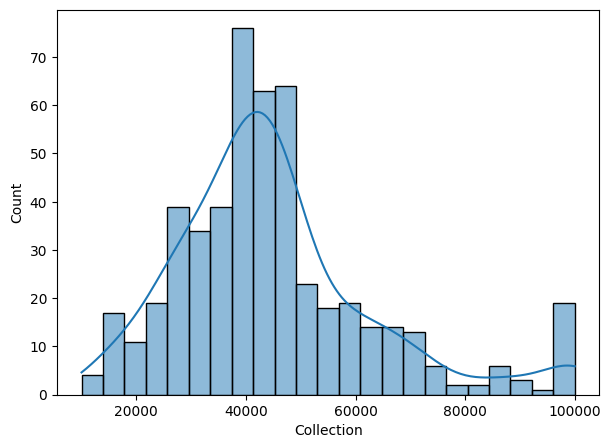

Correlation with Target


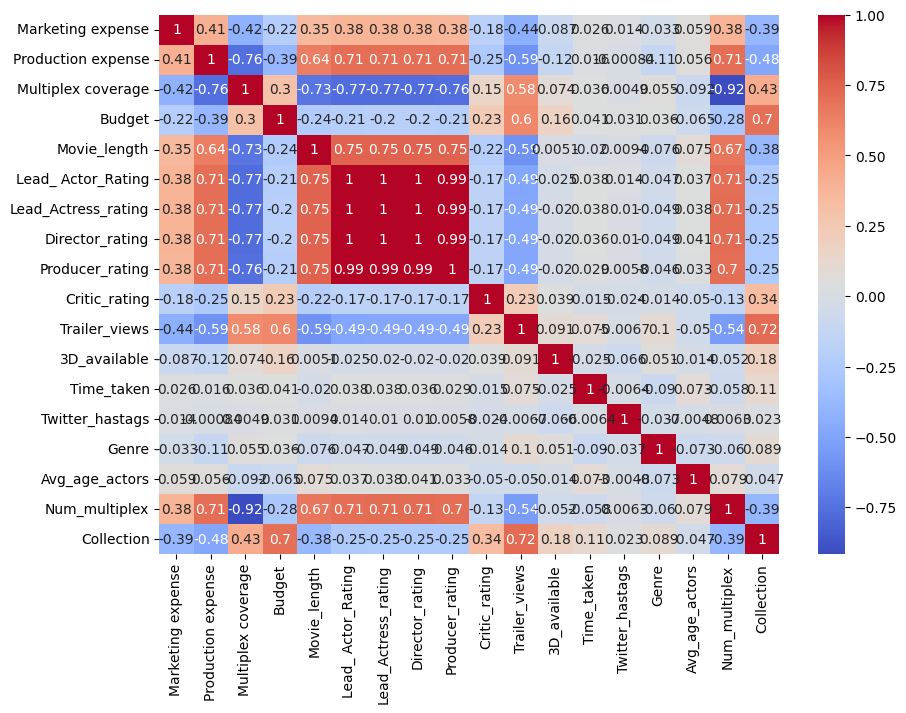



CLASSIFICATION DATASET
Shape
(506, 19)
Columns
Index(['Marketing expense', 'Production expense', 'Multiplex coverage',
       'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating',
       'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views',
       '3D_available', 'Time_taken', 'Twitter_hastags', 'Genre',
       'Avg_age_actors', 'Num_multiplex', 'Collection', 'Start_Tech_Oscar'],
      dtype='object')
Data Types
Marketing expense      float64
Production expense     float64
Multiplex coverage     float64
Budget                 float64
Movie_length           float64
Lead_ Actor_Rating     float64
Lead_Actress_rating    float64
Director_rating        float64
Producer_rating        float64
Critic_rating          float64
Trailer_views            int64
3D_available            object
Time_taken             float64
Twitter_hastags        float64
Genre                   object
Avg_age_actors           int64
Num_multiplex            int64
Collection          

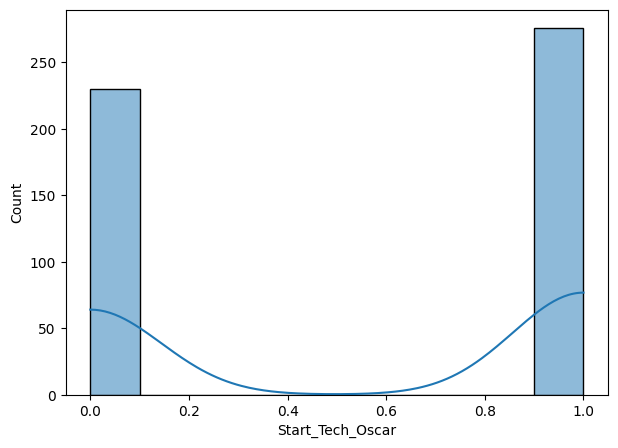

Correlation with Target


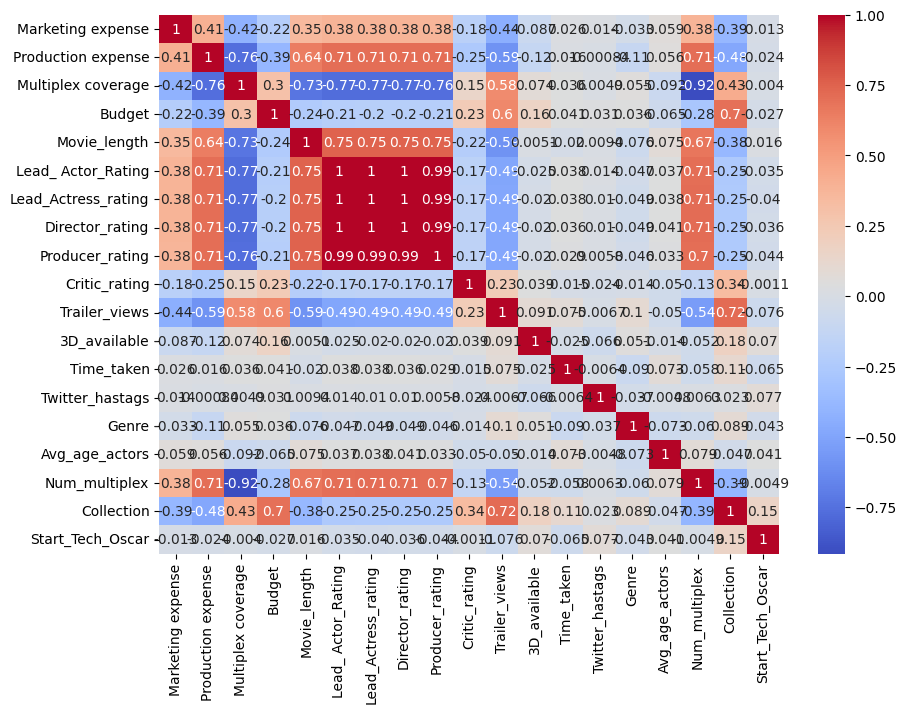

In [9]:
def perform_eda(df, target):

    print("="*70)
    print("Shape")
    print(df.shape)

    print("="*70)
    print("Columns")
    print(df.columns)

    print("="*70)
    print("Data Types")
    print(df.dtypes)

    print("="*70)
    print("Missing Values")
    print(df.isnull().sum())

    print("="*70)
    print("Duplicate Rows")
    print(df.duplicated().sum())

    print("="*70)
    print("Summary Statistics")
    print(df.describe())

    print("="*70)
    print("Target Distribution")

    plt.figure(figsize=(7,5))

    if df[target].dtype=="object":
        sns.countplot(x=df[target])
    else:
        sns.histplot(df[target], kde=True)

    plt.show()

    print("="*70)
    print("Correlation with Target")

    temp=df.copy()

    for col in temp.columns:
        if temp[col].dtype=="object":
            temp[col]=LabelEncoder().fit_transform(temp[col].astype(str))

    corr=temp.corr(numeric_only=True)

    plt.figure(figsize=(10,7))
    sns.heatmap(corr,annot=True,cmap="coolwarm")
    plt.show()

   # ==============================
# EDA
# ==============================

print("REGRESSION DATASET")
perform_eda(reg_df,"Collection")

print("\n\nCLASSIFICATION DATASET")
perform_eda(clf_df,"Start_Tech_Oscar")

Preprocessing


In [10]:


def preprocess(df,target):

    df=df.copy()

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Fill missing values
    for col in df.columns:

        if df[col].dtype=="object":
            df[col].fillna(df[col].mode()[0],inplace=True)

        else:
            df[col].fillna(df[col].median(),inplace=True)

    # Encode categorical columns

    le=LabelEncoder()

    for col in df.columns:

        if df[col].dtype=="object":

            df[col]=le.fit_transform(df[col].astype(str))

    X=df.drop(target,axis=1)
    y=df[target]

    return X,y

Features and Target

In [11]:
# ==============================
# FEATURES & TARGET
# ==============================

X_reg,y_reg=preprocess(reg_df,"Collection")
X_clf,y_clf=preprocess(clf_df,"Start_Tech_Oscar")

print(X_reg.shape,y_reg.shape)
print(X_clf.shape,y_clf.shape)

(506, 17) (506,)
(506, 18) (506,)


Test Train Split

In [15]:


X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_train_clf,X_test_clf,y_train_clf,y_test_clf=train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

Regression MOdel

In [16]:


reg_model=DecisionTreeRegressor(random_state=42)

reg_model.fit(X_train_reg,y_train_reg)

pred_reg=reg_model.predict(X_test_reg)

mae=mean_absolute_error(y_test_reg,pred_reg)
mse=mean_squared_error(y_test_reg,pred_reg)
rmse=np.sqrt(mse)
r2=r2_score(y_test_reg,pred_reg)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 5035.294117647059
MSE : 41606274.50980392
RMSE : 6450.292591022823
R2 : 0.8589508050392207


Classification Model

In [17]:


clf_model=DecisionTreeClassifier(random_state=42)

clf_model.fit(X_train_clf,y_train_clf)

pred_clf=clf_model.predict(X_test_clf)

print("Accuracy :",accuracy_score(y_test_clf,pred_clf))

print("Precision :",precision_score(y_test_clf,pred_clf))

print("Recall :",recall_score(y_test_clf,pred_clf))

print("F1 Score :",f1_score(y_test_clf,pred_clf))

print(classification_report(y_test_clf,pred_clf))

Accuracy : 0.5980392156862745
Precision : 0.7111111111111111
Recall : 0.5333333333333333
F1 Score : 0.6095238095238096
              precision    recall  f1-score   support

           0       0.51      0.69      0.59        42
           1       0.71      0.53      0.61        60

    accuracy                           0.60       102
   macro avg       0.61      0.61      0.60       102
weighted avg       0.63      0.60      0.60       102



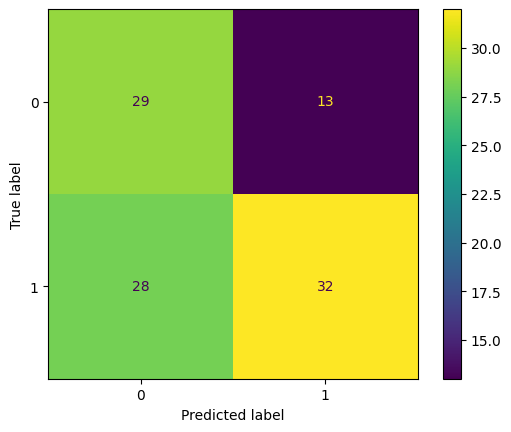

In [18]:
cm=confusion_matrix(y_test_clf,pred_clf)

disp=ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

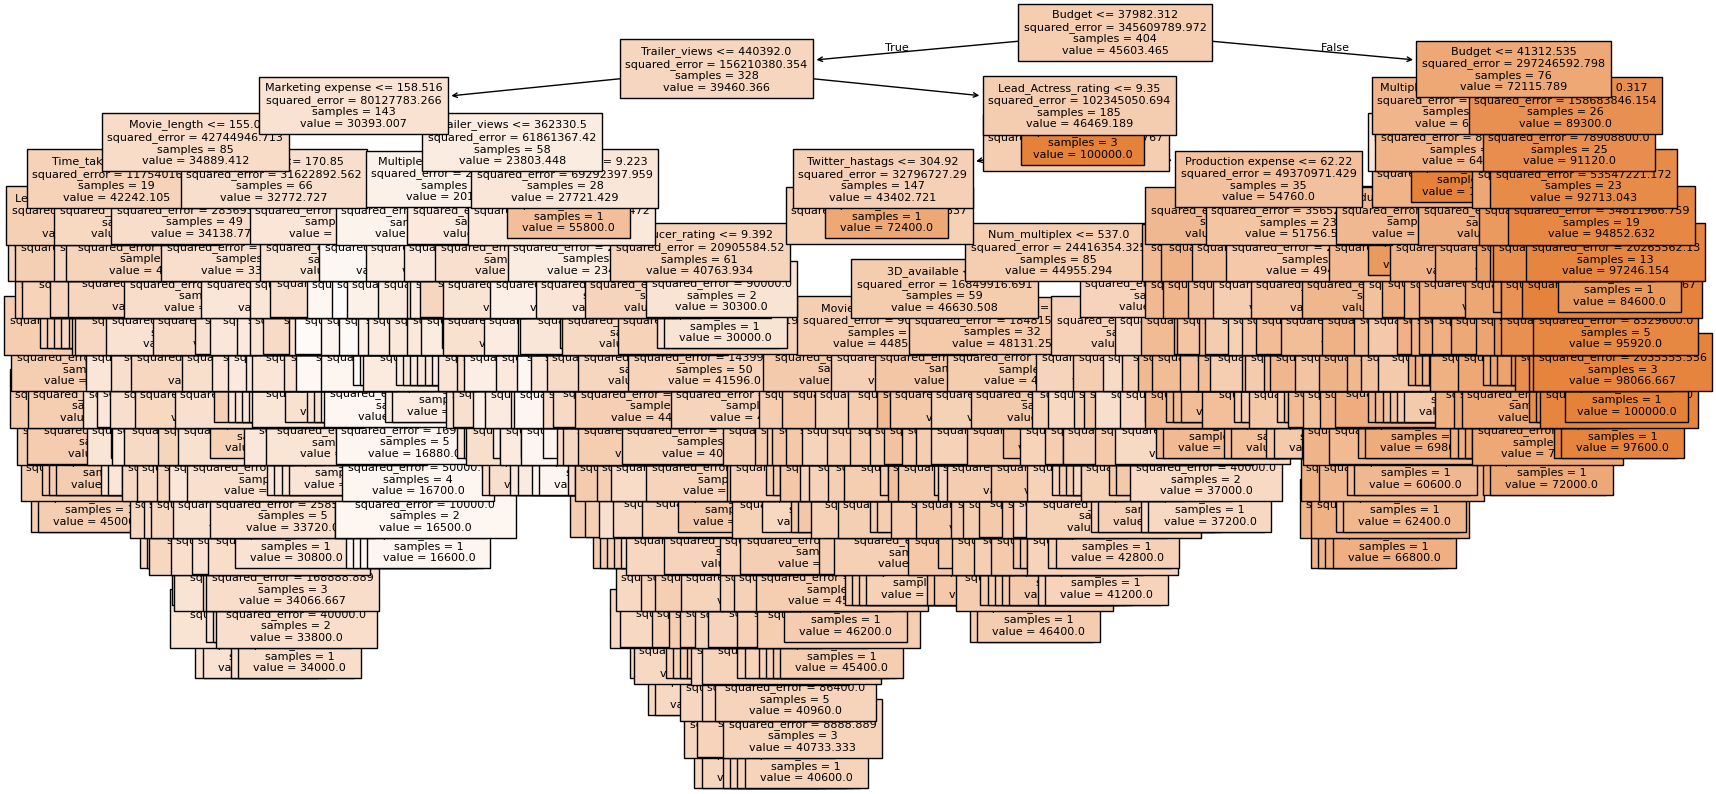

In [19]:
# ==============================
# REGRESSION TREE
# ==============================

plt.figure(figsize=(20,10))

plot_tree(
    reg_model,
    feature_names=X_reg.columns,
    filled=True,
    fontsize=8
)

plt.show()

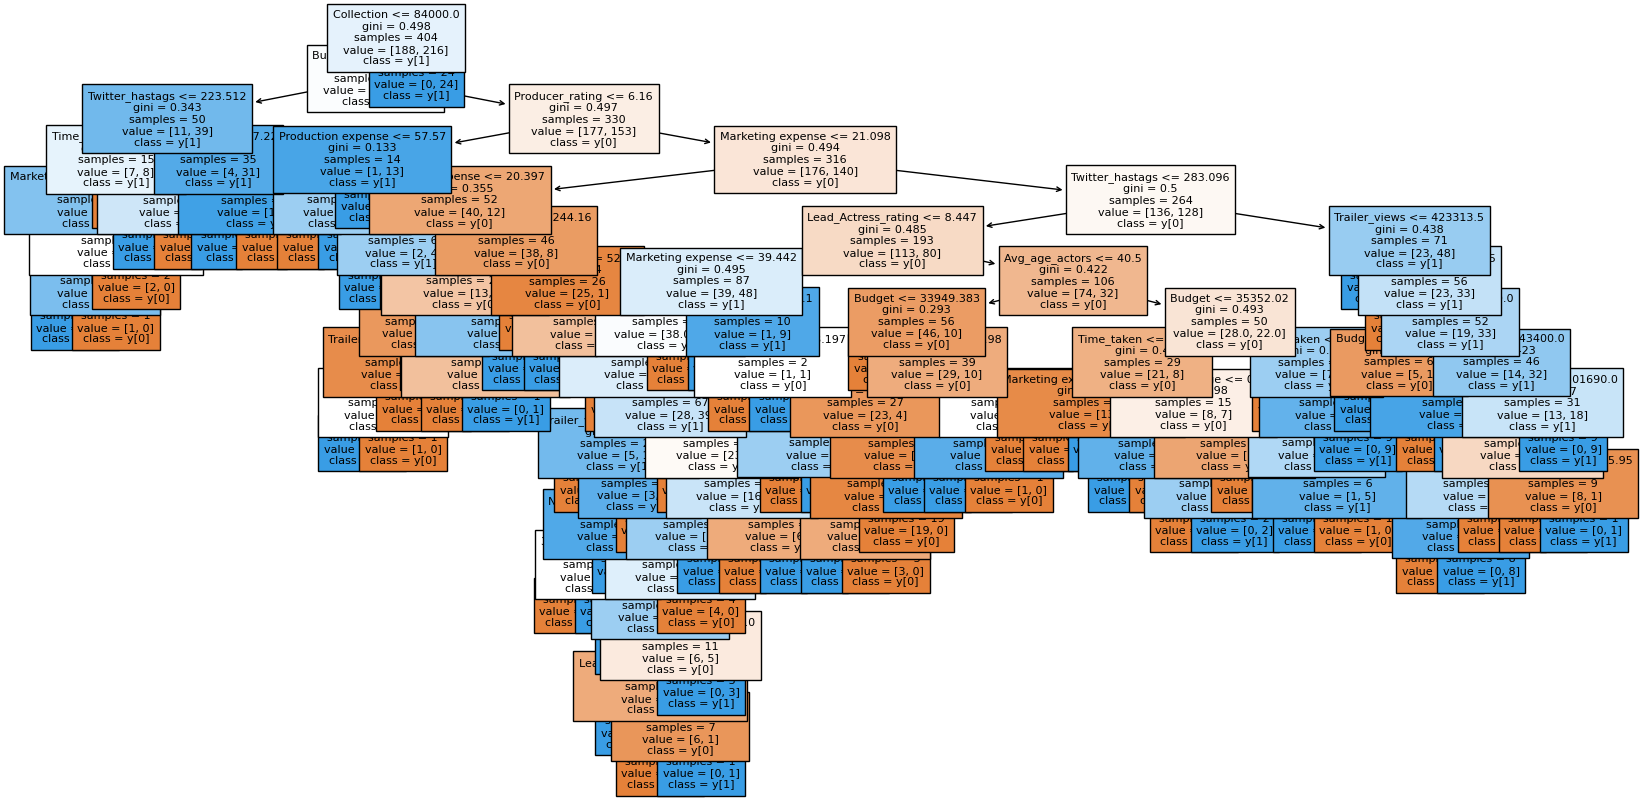

In [20]:
# ==============================
# CLASSIFICATION TREE
# ==============================

plt.figure(figsize=(20,10))

plot_tree(
    clf_model,
    feature_names=X_clf.columns,
    class_names=True,
    filled=True,
    fontsize=8
)

plt.show()

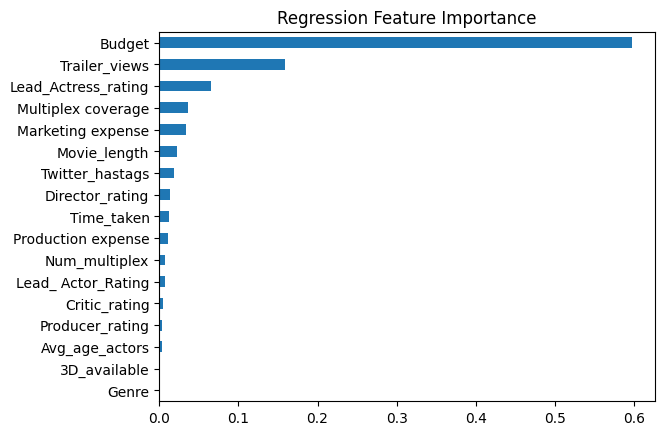

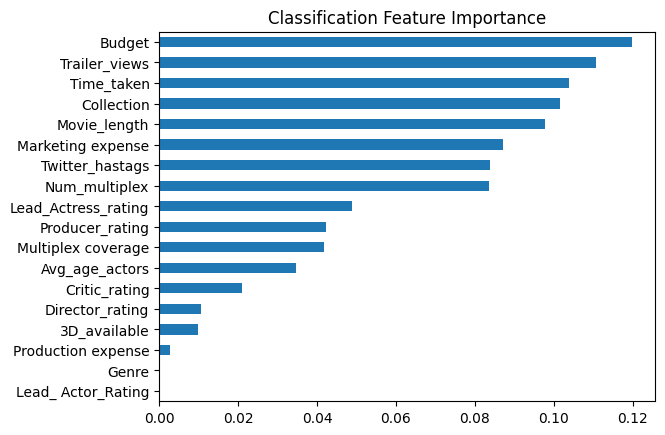

In [21]:
# ==============================
# FEATURE IMPORTANCE
# ==============================

importance_reg=pd.Series(
    reg_model.feature_importances_,
    index=X_reg.columns
).sort_values()

importance_reg.plot(kind="barh")

plt.title("Regression Feature Importance")

plt.show()

importance_clf=pd.Series(
    clf_model.feature_importances_,
    index=X_clf.columns
).sort_values()

importance_clf.plot(kind="barh")

plt.title("Classification Feature Importance")

plt.show()

In [22]:
param_grid={
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_leaf_nodes":[10,20,30,None],
    "ccp_alpha":[0,0.001,0.01]
}

grid_reg=GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_reg.fit(X_train_reg,y_train_reg)

print(grid_reg.best_params_)

{'ccp_alpha': 0, 'max_depth': 5, 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [23]:
grid_clf=GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    param_grid={

        "max_depth":[3,5,7,10],

        "min_samples_split":[2,5,10],

        "min_samples_leaf":[1,2,4],

        "max_leaf_nodes":[10,20,30,None],

        "ccp_alpha":[0,0.001,0.01]

    },

    cv=5,

    scoring="accuracy"

)

grid_clf.fit(X_train_clf,y_train_clf)

print(grid_clf.best_params_)

{'ccp_alpha': 0.01, 'max_depth': 5, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


Train Pruned Model

In [25]:
best_reg=grid_reg.best_estimator_
best_clf=grid_clf.best_estimator_

print("Regression Train Score:",best_reg.score(X_train_reg,y_train_reg))
print("Regression Test Score:",best_reg.score(X_test_reg,y_test_reg))

print()

print("Classification Train Score:",best_clf.score(X_train_clf,y_train_clf))
print("Classification Test Score:",best_clf.score(X_test_clf,y_test_clf))

print()

print("Regression Tree Depth:",best_reg.get_depth())
print("Regression Leaves:",best_reg.get_n_leaves())

print()

print("Classification Tree Depth:",best_clf.get_depth())
print("Classification Leaves:",best_clf.get_n_leaves())

Regression Train Score: 0.9116127433293694
Regression Test Score: 0.8644010938617048

Classification Train Score: 0.6856435643564357
Classification Test Score: 0.5392156862745098

Regression Tree Depth: 5
Regression Leaves: 22

Classification Tree Depth: 5
Classification Leaves: 6


Model Comparison Table

In [26]:
comparison=pd.DataFrame({

    "Model":[
        "Regression Before",
        "Regression After",
        "Classification Before",
        "Classification After"
    ],

    "Train Score":[

        reg_model.score(X_train_reg,y_train_reg),

        best_reg.score(X_train_reg,y_train_reg),

        clf_model.score(X_train_clf,y_train_clf),

        best_clf.score(X_train_clf,y_train_clf)

    ],

    "Test Score":[

        reg_model.score(X_test_reg,y_test_reg),

        best_reg.score(X_test_reg,y_test_reg),

        clf_model.score(X_test_clf,y_test_clf),

        best_clf.score(X_test_clf,y_test_clf)

    ]

})

comparison

,Model,Train Score,Test Score
0,Regression Before,1.000000,0.858951
1,Regression After,0.911613,0.864401
2,Classification Before,1.000000,0.598039
3,Classification After,0.685644,0.539216


### Observation
- Dataset shape and column names were examined.
- Missing values were identified and handled.
- Duplicate rows were removed.
- Correlation heatmap shows the relationship among variables.
- Target distribution indicates whether the data is balanced or skewed.

Markdown After Baseline Model
### Observation
The initial decision tree achieved the above performance metrics. If the training score is much higher than the testing score, the model is likely overfitting.

### Observation
- Root node is the most important feature.
- Internal nodes represent decision conditions.
- Leaf nodes contain the final prediction.
- More depth generally indicates a more complex model.

Markdown After Pruning
### Observation
Pruning reduced tree complexity. The difference between train and test scores became smaller, indicating better generalization and reduced overfitting.

Final Conclusion

# Final Conclusion

1. Decision Tree Regression predicts the Collection value using numerical splitting.

2. Decision Tree Classification predicts Start_Tech_Oscar into different classes.

3. Feature Importance identifies the most influential variables.

4. Pruning reduced model complexity and improved generalization.

5. If train accuracy is much higher than test accuracy, the model is overfitting.

6. Decision Trees are highly interpretable because the entire decision-making process can be visualized.

7. The pruned model is preferred because it balances prediction accuracy and interpretability.

PartA

In [27]:
# ==========================================================
# PART A - ANALYSIS OF UNPRUNED DECISION TREES
# ==========================================================

print("============== REGRESSION ==============")

print("Train Score :", reg_model.score(X_train_reg, y_train_reg))
print("Test Score  :", reg_model.score(X_test_reg, y_test_reg))

print("Tree Depth :", reg_model.get_depth())
print("Number of Leaves :", reg_model.get_n_leaves())

print("\n============== CLASSIFICATION ==============")

print("Train Score :", clf_model.score(X_train_clf, y_train_clf))
print("Test Score  :", clf_model.score(X_test_clf, y_test_clf))

print("Tree Depth :", clf_model.get_depth())
print("Number of Leaves :", clf_model.get_n_leaves())

============== REGRESSION ==============
Train Score : 1.0
Test Score  : 0.8589508050392207
Tree Depth : 20
Number of Leaves : 379

============== CLASSIFICATION ==============
Train Score : 1.0
Test Score  : 0.5980392156862745
Tree Depth : 18
Number of Leaves : 79


## Part A Answers

1. The train and test scores are shown above.
2. If the training score is much higher than the testing score, the model is overfitting.
3. A very large tree depth indicates that the tree became too deep.
4. A high number of leaf nodes indicates a complex model.
5. Very small leaves suggest that the tree memorized the training data.
6. The root node can be identified from the tree visualization.
7. Features near the root are the most important for prediction.
8. The unpruned tree is usually difficult to explain because of excessive complexity.
9. The model is considered overfitting if train performance is much better than test performance.
10. Test score is more reliable because it represents unseen data.

## Part B Answers

1. max_depth controls the maximum depth of the tree.

2. min_samples_leaf controls very small leaf nodes.

3. max_leaf_nodes limits the total number of business segments.

4. Cross-validation uses multiple train-test splits, making evaluation more reliable.

5. XGBoost combines many trees and corrects previous mistakes, usually giving better prediction accuracy.

In [28]:
# ==========================================================
# PRE-PRUNING REGRESSION
# ==========================================================

pre_reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=25,
    random_state=42
)

pre_reg.fit(X_train_reg, y_train_reg)

pred = pre_reg.predict(X_test_reg)

print("MAE :", mean_absolute_error(y_test_reg,pred))
print("MSE :", mean_squared_error(y_test_reg,pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg,pred)))
print("R2 :", r2_score(y_test_reg,pred))

print()

print("Depth :", pre_reg.get_depth())
print("Leaves :", pre_reg.get_n_leaves())

MAE : 5958.8590714031025
MSE : 59018027.253415324
RMSE : 7682.3191324895715
R2 : 0.7999233209330956

Depth : 5
Leaves : 22


Accuracy : 0.5392156862745098
Precision : 0.6585365853658537
Recall : 0.45
F1 : 0.5346534653465347

Depth : 5
Leaves : 12


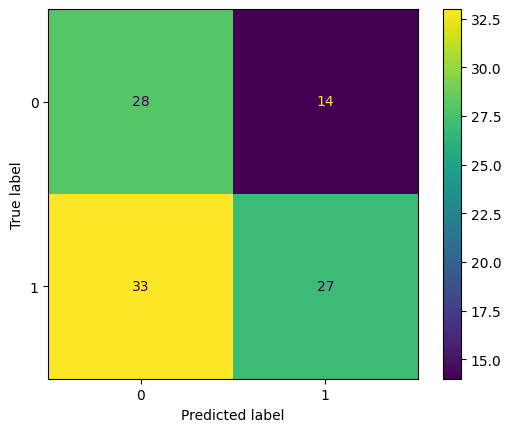

In [29]:
# ==========================================================
# PRE-PRUNING CLASSIFICATION
# ==========================================================

pre_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=25,
    random_state=42
)

pre_clf.fit(X_train_clf,y_train_clf)

pred = pre_clf.predict(X_test_clf)

print("Accuracy :",accuracy_score(y_test_clf,pred))
print("Precision :",precision_score(y_test_clf,pred))
print("Recall :",recall_score(y_test_clf,pred))
print("F1 :",f1_score(y_test_clf,pred))

print()

print("Depth :",pre_clf.get_depth())
print("Leaves :",pre_clf.get_n_leaves())

ConfusionMatrixDisplay.from_predictions(y_test_clf,pred)

plt.show()

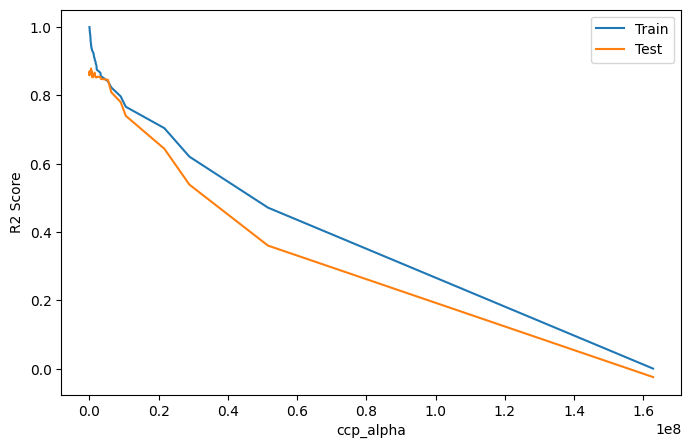

Best Alpha : 470605.4230422997


In [30]:
# ==========================================================
# POST PRUNING REGRESSION
# ==========================================================

path = reg_model.cost_complexity_pruning_path(X_train_reg,y_train_reg)

alphas = path.ccp_alphas

train_score=[]
test_score=[]

for alpha in alphas:

    model=DecisionTreeRegressor(ccp_alpha=alpha,random_state=42)

    model.fit(X_train_reg,y_train_reg)

    train_score.append(model.score(X_train_reg,y_train_reg))

    test_score.append(model.score(X_test_reg,y_test_reg))

plt.figure(figsize=(8,5))

plt.plot(alphas,train_score,label="Train")

plt.plot(alphas,test_score,label="Test")

plt.xlabel("ccp_alpha")

plt.ylabel("R2 Score")

plt.legend()

plt.show()

best_alpha=alphas[np.argmax(test_score)]

print("Best Alpha :",best_alpha)

In [31]:
post_reg=DecisionTreeRegressor(
    ccp_alpha=best_alpha,
    random_state=42
)

post_reg.fit(X_train_reg,y_train_reg)

pred=post_reg.predict(X_test_reg)

print("RMSE :",np.sqrt(mean_squared_error(y_test_reg,pred)))

print("R2 :",r2_score(y_test_reg,pred))

print("Depth :",post_reg.get_depth())

print("Leaves :",post_reg.get_n_leaves())

RMSE : 5981.868265763303
R2 : 0.8786931093651743
Depth : 8
Leaves : 31


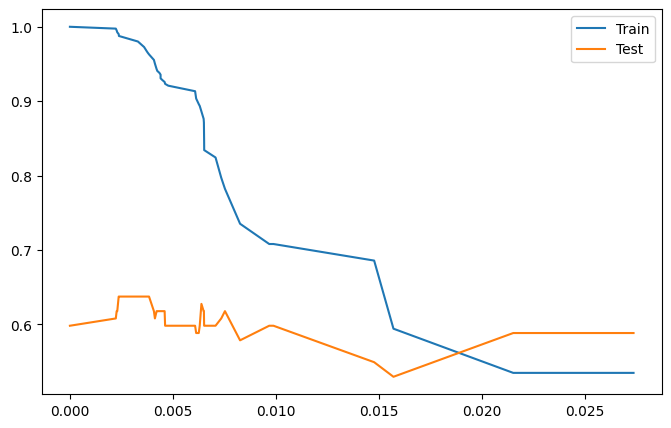

0.002367628067154542


In [32]:
path=clf_model.cost_complexity_pruning_path(
    X_train_clf,
    y_train_clf
)

alphas=path.ccp_alphas

train=[]
test=[]

for alpha in alphas:

    model=DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train_clf,y_train_clf)

    train.append(model.score(X_train_clf,y_train_clf))

    test.append(model.score(X_test_clf,y_test_clf))

plt.figure(figsize=(8,5))

plt.plot(alphas,train,label="Train")

plt.plot(alphas,test,label="Test")

plt.legend()

plt.show()

best_alpha=alphas[np.argmax(test)]

print(best_alpha)

In [33]:
post_clf=DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42
)

post_clf.fit(X_train_clf,y_train_clf)

pred=post_clf.predict(X_test_clf)

print(classification_report(y_test_clf,pred))

print("Depth :",post_clf.get_depth())

print("Leaves :",post_clf.get_n_leaves())

              precision    recall  f1-score   support

           0       0.54      0.76      0.63        42
           1       0.77      0.55      0.64        60

    accuracy                           0.64       102
   macro avg       0.65      0.66      0.64       102
weighted avg       0.67      0.64      0.64       102

Depth : 18
Leaves : 71


Cross Validation

In [34]:
# ==========================================================
# CROSS VALIDATION
# ==========================================================

from sklearn.model_selection import cross_val_score

print("Regression CV")

scores=cross_val_score(
    post_reg,
    X_reg,
    y_reg,
    cv=5,
    scoring="r2"
)

print(scores)

print("Average :",scores.mean())

print()

print("Classification CV")

scores=cross_val_score(
    post_clf,
    X_clf,
    y_clf,
    cv=5,
    scoring="accuracy"
)

print(scores)

print("Average :",scores.mean())

Regression CV
[0.57056906 0.72845233 0.54778366 0.29501875 0.11825414]
Average : 0.45201558885520177

Classification CV
[0.44117647 0.63366337 0.5049505  0.57425743 0.56435644]
Average : 0.5436808386721025


In [35]:
# ==========================================================
# GRID SEARCH
# ==========================================================

param_grid={

    "max_depth":[3,5,7,10],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,5],

    "max_leaf_nodes":[10,20,30],

    "ccp_alpha":[0,0.001,0.01]

}

grid_reg=GridSearchCV(

    DecisionTreeRegressor(random_state=42),

    param_grid,

    cv=5,

    scoring="r2"

)

grid_reg.fit(X_train_reg,y_train_reg)

print("Regression Best Parameters")

print(grid_reg.best_params_)

print(grid_reg.best_score_)

print()

grid_clf=GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy"

)

grid_clf.fit(X_train_clf,y_train_clf)

print("Classification Best Parameters")

print(grid_clf.best_params_)

print(grid_clf.best_score_)

Regression Best Parameters
{'ccp_alpha': 0, 'max_depth': 5, 'max_leaf_nodes': 30, 'min_samples_leaf': 2, 'min_samples_split': 2}
0.7383617826372078

Classification Best Parameters
{'ccp_alpha': 0.01, 'max_depth': 5, 'max_leaf_nodes': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
0.6138271604938271


In [36]:
!pip install xgboost

Regression
RMSE : 5746.125825284372
MAE : 4175.5498046875
R2 : 0.8880659937858582

Classification
Accuracy : 0.6274509803921569
Precision : 0.6896551724137931
Recall : 0.6666666666666666
F1 : 0.6779661016949152


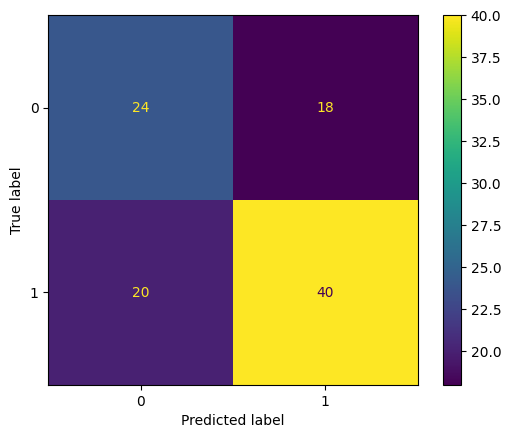

In [37]:
from xgboost import XGBRegressor
from xgboost import XGBClassifier

# Regression

xgb_reg=XGBRegressor(random_state=42)

xgb_reg.fit(X_train_reg,y_train_reg)

pred=xgb_reg.predict(X_test_reg)

print("Regression")

print("RMSE :",np.sqrt(mean_squared_error(y_test_reg,pred)))

print("MAE :",mean_absolute_error(y_test_reg,pred))

print("R2 :",r2_score(y_test_reg,pred))

print()

# Classification

xgb_clf=XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_clf.fit(X_train_clf,y_train_clf)

pred=xgb_clf.predict(X_test_clf)

print("Classification")

print("Accuracy :",accuracy_score(y_test_clf,pred))

print("Precision :",precision_score(y_test_clf,pred))

print("Recall :",recall_score(y_test_clf,pred))

print("F1 :",f1_score(y_test_clf,pred))

ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    pred
)

plt.show()

In [38]:
comparison_reg = pd.DataFrame({

    "Model":[

        "Unpruned DT",

        "Pre-pruned DT",

        "Post-pruned DT",

        "Cross Validated DT",

        "XGBoost"

    ],

    "Train Score":[

        reg_model.score(X_train_reg,y_train_reg),

        pre_reg.score(X_train_reg,y_train_reg),

        post_reg.score(X_train_reg,y_train_reg),

        grid_reg.best_estimator_.score(X_train_reg,y_train_reg),

        np.nan

    ],

    "Test RMSE":[

        np.sqrt(mean_squared_error(y_test_reg,reg_model.predict(X_test_reg))),

        np.sqrt(mean_squared_error(y_test_reg,pre_reg.predict(X_test_reg))),

        np.sqrt(mean_squared_error(y_test_reg,post_reg.predict(X_test_reg))),

        np.sqrt(mean_squared_error(y_test_reg,grid_reg.best_estimator_.predict(X_test_reg))),

        np.sqrt(mean_squared_error(y_test_reg,xgb_reg.predict(X_test_reg)))

    ],

    "Test MAE":[

        mean_absolute_error(y_test_reg,reg_model.predict(X_test_reg)),

        mean_absolute_error(y_test_reg,pre_reg.predict(X_test_reg)),

        mean_absolute_error(y_test_reg,post_reg.predict(X_test_reg)),

        mean_absolute_error(y_test_reg,grid_reg.best_estimator_.predict(X_test_reg)),

        mean_absolute_error(y_test_reg,xgb_reg.predict(X_test_reg))

    ],

    "Test R2":[

        r2_score(y_test_reg,reg_model.predict(X_test_reg)),

        r2_score(y_test_reg,pre_reg.predict(X_test_reg)),

        r2_score(y_test_reg,post_reg.predict(X_test_reg)),

        r2_score(y_test_reg,grid_reg.best_estimator_.predict(X_test_reg)),

        r2_score(y_test_reg,xgb_reg.predict(X_test_reg))

    ]

})

comparison_reg


,Model,Train Score,Test RMSE,Test MAE,Test R2
0,Unpruned DT,1.000000,6450.292591,5035.294118,0.858951
1,Pre-pruned DT,0.868158,7682.319132,5958.859071,0.799923
2,Post-pruned DT,0.945147,5981.868266,4840.243914,0.878693
3,Cross Validated DT,0.911613,6324.441827,5000.120934,0.864401
4,XGBoost,NaN,5746.125825,4175.549805,0.888066


In [39]:
comparison_clf=pd.DataFrame({

    "Model":[

        "Unpruned DT",

        "Pre-pruned DT",

        "Post-pruned DT",

        "Cross Validated DT",

        "XGBoost"

    ],

    "Accuracy":[

        accuracy_score(y_test_clf,reg_model.predict(X_test_reg)) if False else accuracy_score(y_test_clf,clf_model.predict(X_test_clf)),

        accuracy_score(y_test_clf,pre_clf.predict(X_test_clf)),

        accuracy_score(y_test_clf,post_clf.predict(X_test_clf)),

        accuracy_score(y_test_clf,grid_clf.best_estimator_.predict(X_test_clf)),

        accuracy_score(y_test_clf,xgb_clf.predict(X_test_clf))

    ]

})

comparison_clf

,Model,Accuracy
0,Unpruned DT,0.598039
1,Pre-pruned DT,0.539216
2,Post-pruned DT,0.637255
3,Cross Validated DT,0.539216
4,XGBoost,0.627451


CONCLUSION

## Final Conclusion

1. Pruning improved the model by reducing overfitting and improving generalization.
2. The pruned tree was much simpler with fewer leaves and lower depth.
3. Among all hyperparameters, max_depth and ccp_alpha had the greatest effect on model complexity.
4. Cross-validation produced more reliable performance estimates than a single train-test split.
5. GridSearchCV helped identify the optimal hyperparameter combination automatically.
6. XGBoost achieved the best predictive performance because it combines multiple trees using boosting.
7. Decision Trees are the best choice when interpretability and business explanation are important.
8. XGBoost is the preferred model when prediction accuracy is the main objective.
9. Feature importance highlighted the variables that most influenced the target, providing useful business insights.
10. Overall, pruning and cross-validation produced more robust models, while XGBoost delivered the strongest predictive results.